In [ ]:
#!pip install requests matplotlib numpy

import requests
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Mudumalai coordinates
lat = 11.65
lon = 76.5

url = f"https://modis.ornl.gov/rst/api/v1/MOD13Q1/subset?latitude={lat}&longitude={lon}&kmAboveBelow=5&kmLeftRight=5&startDate=A2024001&endDate=A2024020"

response = requests.get(url)
data = response.json()

print("Data fetched successfully!")

Data fetched successfully!


In [3]:
# Extract first time step (you can loop later)
subset = data['subset'][0]

values = subset['data']
nrows = data['nrows']
ncols = data['ncols']

print(f"Grid size: {nrows} x {ncols}")


Grid size: 41 x 41


In [4]:
# Convert to numpy array
grid = np.array(values).reshape(nrows, ncols)

# Scale NDVI (MODIS uses scale factor 0.0001)
ndvi = grid / 10000.0

print("NDVI conversion done!")

NDVI conversion done!


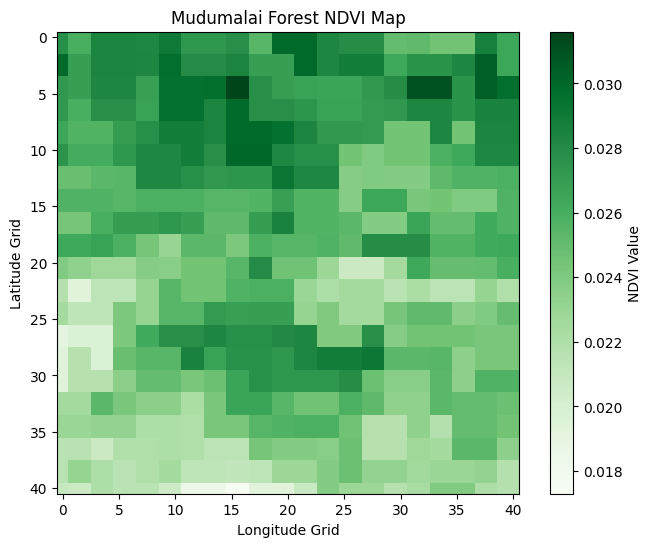

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(ndvi, cmap='Greens')
plt.colorbar(label='NDVI Value')
plt.title("Mudumalai Forest NDVI Map")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

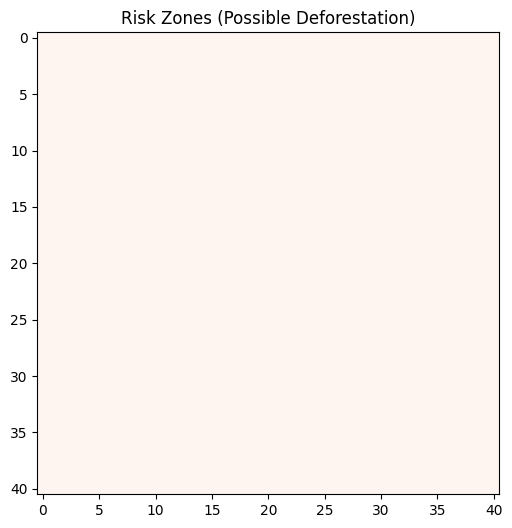

In [6]:
# Threshold for low vegetation
threshold = 0.2

risk_map = ndvi < threshold

plt.figure(figsize=(8, 6))
plt.imshow(risk_map, cmap='Reds')
plt.title("Risk Zones (Possible Deforestation)")
plt.show()

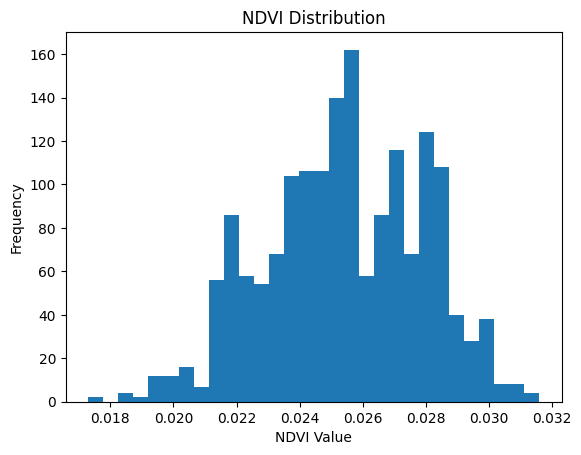

In [7]:
plt.hist(ndvi.flatten(), bins=30)
plt.title("NDVI Distribution")
plt.xlabel("NDVI Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# !pip install folium


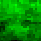

In [10]:
import folium
from folium.raster_layers import ImageOverlay

# Center of Mudumalai
m = folium.Map(location=[11.65, 76.5], zoom_start=11)

# Define bounding box (same as API region)
bounds = [
    [11.65 - 0.05, 76.5 - 0.05],  # bottom-left
    [11.65 + 0.05, 76.5 + 0.05]   # top-right
]

# Normalize NDVI (0–1 → 0–255 for image)
ndvi_norm = (ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())

# Add overlay
ImageOverlay(
    image=ndvi_norm,
    bounds=bounds,
    colormap=lambda x: (0, x, 0, 0.6)  # green overlay
).add_to(m)

m

In [14]:
import folium

m = folium.Map(location=[11.65, 76.5], zoom_start=11)
m
m.save("mudumalai_map_open.html")